# Monte Carlo Simulation with Multiple Random Variables
Monte Carlo simulation is a powerful technique used to understand the behavior of complex systems by using random sampling to obtain numerical results. In this lesson, we will explore how to conduct a Monte Carlo simulation where outcomes depend on draws from multiple random variable distributions. 

We will use the example of 3 slot machines with payouts following normal, uniform, and Poisson distributions. We will also discuss the importance of finite moments and convergence of expectation for the validity of the simulation.


### Q: How do we find the PDF/CDF of a function of multiple random variables?

## Group Discussion Question
Why is Monte Carlo simulation a valuable tool in various fields such as finance, engineering, and science? 

How does the ability to simulate outcomes from multiple random variables enhance our understanding of complex systems? Discuss with your group and provide examples.


## Monte Carlo Simulation Example: Slot Machines
Imagine we have three slot machines, each with a different payout distribution:
1. Slot Machine 1: Payout follows a Normal distribution.
2. Slot Machine 2: Payout follows a Uniform distribution.
3. Slot Machine 3: Payout follows a Poisson distribution.

### Parameters for Each Distribution
- Slot Machine 1 (Normal distribution): Mean ($\mu$) = 50, Standard Deviation ($\sigma$) = 10
- Slot Machine 2 (Uniform distribution): Lower Bound = 20, Upper Bound = 80
- Slot Machine 3 (Poisson distribution): Rate ($\lambda$) = 30

### Conducting the Simulation
We will simulate the outcomes by drawing from these distributions and calculating the average payout over multiple iterations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, poisson

# Parameters
mu, sigma = 50, 10  # Normal distribution parameters
lower, upper = 20, 80  # Uniform distribution parameters
lam = 30  # Poisson distribution parameter
n_iterations = 10000  # Number of iterations

# Lists to store payouts
payouts_normal = []
payouts_uniform = []
payouts_poisson = []
payouts_combined = []

# Conduct the simulation
for _ in range(n_iterations):
    payout_normal = np.random.normal(mu, sigma)
    payout_uniform = np.random.uniform(lower, upper)
    payout_poisson = np.random.poisson(lam)
    
    payouts_normal.append(payout_normal)
    payouts_uniform.append(payout_uniform)
    payouts_poisson.append(payout_poisson)
    
    # Combine the payouts into a tuple and add to the combined list
    payouts_combined.append((payout_normal, payout_uniform, payout_poisson))

# Calculate average payouts
avg_payout_normal = np.mean(payouts_normal)
avg_payout_uniform = np.mean(payouts_uniform)
avg_payout_poisson = np.mean(payouts_poisson)

# Print average payouts
print(f'Average Payout (Normal): {avg_payout_normal:.2f}')
print(f'Average Payout (Uniform): {avg_payout_uniform:.2f}')
print(f'Average Payout (Poisson): {avg_payout_poisson:.2f}')

Average Payout (Normal): 50.02
Average Payout (Uniform): 49.69
Average Payout (Poisson): 29.94


### Visualizing the Payout Distributions
Let's plot the distribution of payouts for each slot machine to understand their behavior.



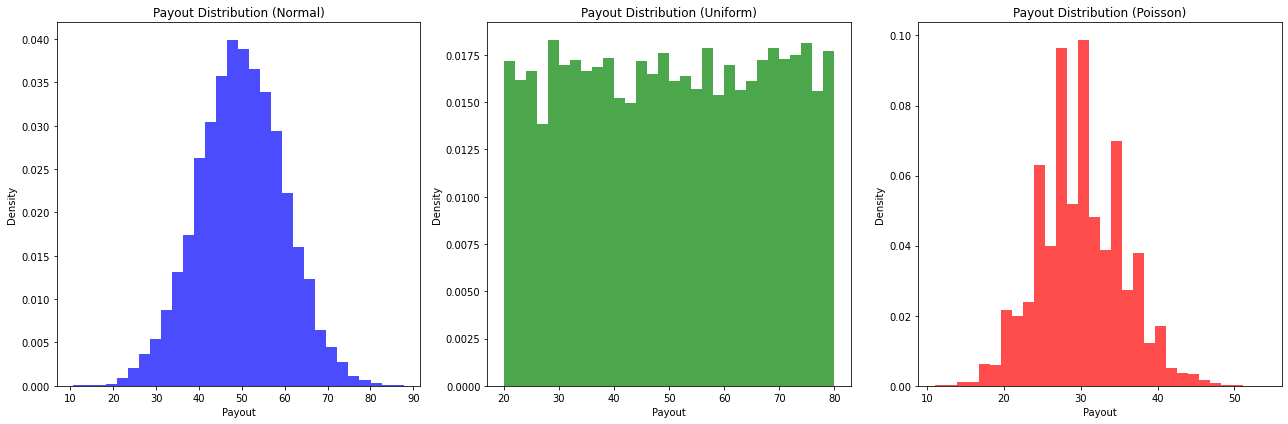

In [3]:
# Plot the distribution of payouts
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(payouts_normal, bins=30, density=True, alpha=0.7, color='blue')
plt.title('Payout Distribution (Normal)')
plt.xlabel('Payout')
plt.ylabel('Density')

plt.subplot(1, 3, 2)
plt.hist(payouts_uniform, bins=30, density=True, alpha=0.7, color='green')
plt.title('Payout Distribution (Uniform)')
plt.xlabel('Payout')
plt.ylabel('Density')

plt.subplot(1, 3, 3)
plt.hist(payouts_poisson, bins=30, density=True, alpha=0.7, color='red')
plt.title('Payout Distribution (Poisson)')
plt.xlabel('Payout')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

### Distribution of Payouts Random Variable

We can now visualize the distribution of payouts which is a reasonable proxy for the density and can compute necessary statistics like expectation and variance.

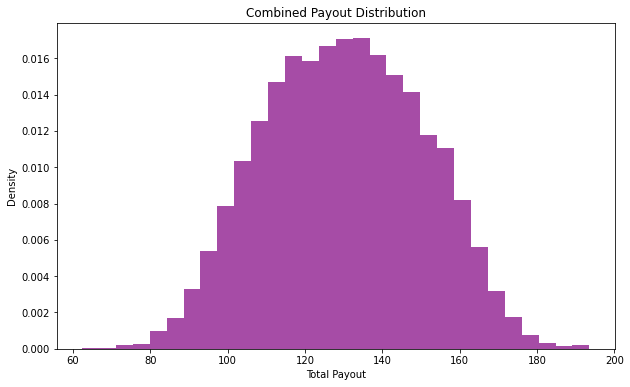

In [5]:
# Extract combined payouts
combined_payouts = [sum(payout) for payout in payouts_combined]

# Plot the combined payout distribution
plt.figure(figsize=(10, 6))
plt.hist(combined_payouts, bins=30, density=True, alpha=0.7, color='purple')
plt.title('Combined Payout Distribution')
plt.xlabel('Total Payout')
plt.ylabel('Density')
plt.show()

124.09698859188852


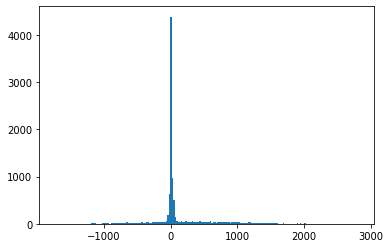

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, poisson

# Parameters
m1, s1 = 367.2, 367.2*2  # Normal distribution parameters
m2, s2 = 5 *np.e, 5 *np.e*2
m3, s3 = np.pi ** (1/2), np.pi ** (1/2)*2

j = []

for i in range(10000):
    U = np.random.uniform(0, 1)
    if U < 1/3:
        M = np.random.normal(m1, s1)
    elif 1/3 <= U < 2/3:
        M = np.random.normal(m2, s2)
    else:
        M = np.random.normal(m3, s3)
    j.append(M)

print(np.mean(j))
plt.hist(j, bins=200)
plt.show()

In [18]:
(367.2 + 5*np.e + (np.pi ** (1/2))) / 3

127.52128766440023

### Discussion on Finite Moments and Convergence of Expectation
For a Monte Carlo simulation to be valid, the random variables involved must have finite moments (e.g., mean, variance). This ensures that the expectation converges as the number of iterations increases. Without finite moments, the simulation results may not converge, leading to unreliable outcomes.

### Importance of Finite Moments
Finite moments are crucial because they provide a measure of the central tendency and dispersion of the distribution. When moments are finite, it ensures that the sample mean and other statistics will converge to their true values as the number of iterations increases.

### Example of Non-Finite Moments
An example of a distribution with non-finite moments is the Cauchy distribution, which has undefined mean and variance. Simulating such distributions would not lead to meaningful or convergent results.



### Practice Problems
1. Conduct a Monte Carlo simulation for a slot machine with an Exponential distribution for payouts (mean $\mu$ = 40). Plot the payout distribution and calculate the average payout.

2. Simulate a scenario where two slot machines have payouts following different distributions (e.g., Beta and Gamma distributions). Plot the payout distributions and discuss the results.

3. Explain the importance of the Central Limit Theorem in the context of Monte Carlo simulations. How does the CLT justify the use of simulation for approximating expectations?

4. Discuss the limitations of Monte Carlo simulations. Provide examples where simulations may not yield reliable results due to the nature of the random variables involved.

### Conclusion
In this lesson, we conducted a Monte Carlo simulation with payouts from three different slot machines following normal, uniform, and Poisson distributions. We observed the distribution of payouts and calculated the average payouts for each machine. It is essential to ensure that the random variables involved in a simulation have finite moments and that their expectations converge to obtain reliable and meaningful results.
